In [1]:
import sys
from pathlib import Path

# Make src/ importable from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

from src.data.annotations import load_as_dataframe, get_pair_rows, list_unique_pairs
from src.data.images import load_scene_image

/Users/p/code/dtu/adlcv/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = load_as_dataframe("train")
print(f"Train rows: {len(df):,}")
df.head()

Train rows: 15,917,203


,entry_id,bg_path,fg_class,bbox,label,image_reward_score,confidence,source
0,1,data_large_standard/k/kitchen/00002986.jpg,bottle,"[0.542969, 0.591797, 0.0625, 0.152344]",1,-1.542461,0.388181,ho
1,1,data_large_standard/k/kitchen/00002986.jpg,bottle,"[0.542969, 0.587891, 0.0625, 0.158203]",1,-1.598204,0.388575,ho
2,1,data_large_standard/k/kitchen/00002986.jpg,bottle,"[0.574219, 0.671875, 0.082031, 0.255859]",1,-0.420639,0.739268,ho
3,1,data_large_standard/k/kitchen/00002986.jpg,bottle,"[0.574219, 0.568359, 0.083984, 0.253906]",1,-1.412825,0.372770,ho
4,1,data_large_standard/k/kitchen/00002986.jpg,bottle,"[0.554688, 0.806641, 0.128906, 0.191406]",1,-0.831861,0.527968,ho


bottle candidates in this kitchen: 16


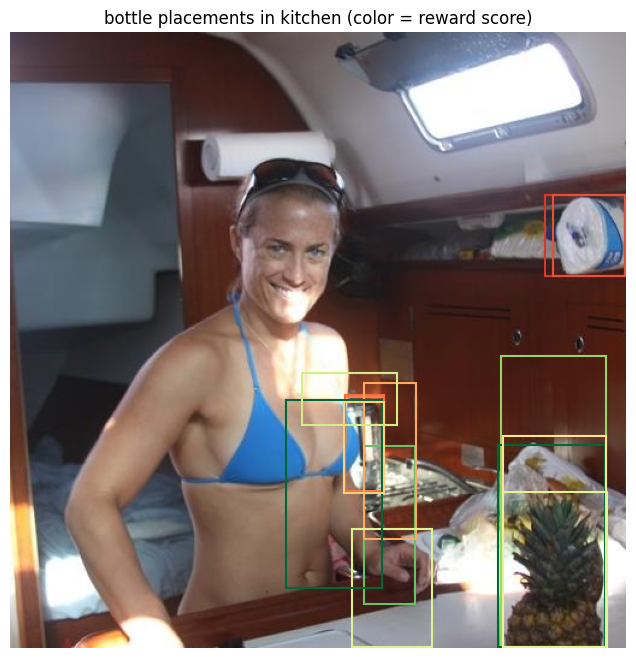

In [3]:
bg_path = "data_large_standard/k/kitchen/00002986.jpg"
fg_class = "bottle"

sub = get_pair_rows(df, bg_path, fg_class, label=1)
print(f"{fg_class} candidates in this kitchen: {len(sub)}")

img = load_scene_image(bg_path)

# Convert normalized bboxes to pixel coords (512x512)
bboxes = np.array(sub["bbox"].tolist()) * 512
scores = sub["image_reward_score"].values

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
for (x, y, w, h), score in zip(bboxes, scores):
    color = plt.cm.RdYlGn((score + 2) / 2)  # higher score = greener
    rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=1.5)
    ax.add_patch(rect)
ax.set_title(f"{fg_class} placements in kitchen (color = reward score)")
ax.axis("off")
plt.show()

/Users/p/code/dtu/adlcv/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Target shape: (8, 32, 32), sum: 1.0000
2D heatmap shape: (32, 32)


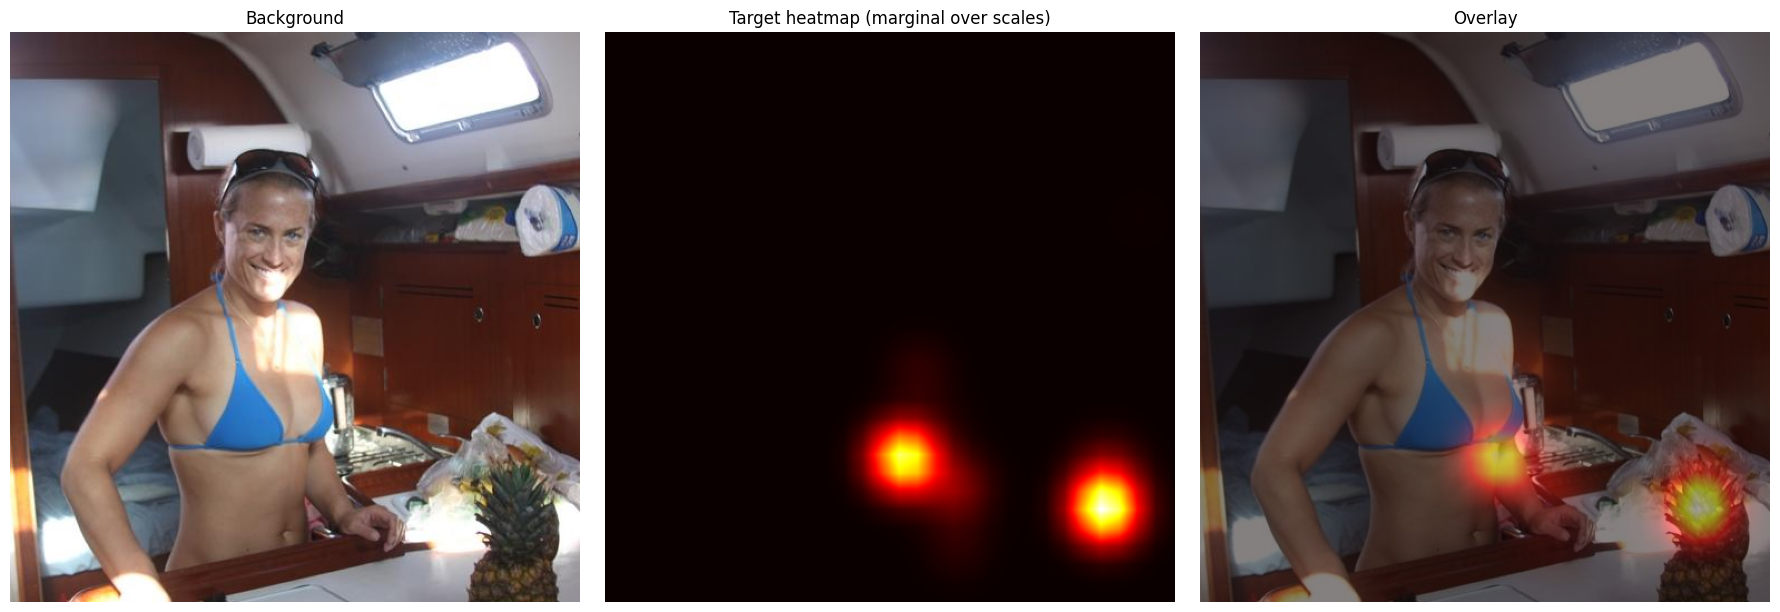

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src.data.annotations import load_as_dataframe, get_pair_rows
from src.data.images import load_scene_image
from src.partA.scale_bins import load_edges
from src.partA.targets import build_target_tensor

df = load_as_dataframe("train")
edges = load_edges()

bg_path = "data_large_standard/k/kitchen/00002986.jpg"
fg_class = "bottle"

rows = get_pair_rows(df, bg_path, fg_class, label=1)
target = build_target_tensor(rows, scale_bin_edges=edges)
print(f"Target shape: {target.shape}, sum: {target.sum():.4f}")

img = load_scene_image(bg_path)

# Marginal over scales: sum the 8 scale bins to get a 2D heatmap of "where"
target_2d = target.sum(axis=0)
print(f"2D heatmap shape: {target_2d.shape}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img)
axes[0].set_title("Background")
axes[0].axis("off")

# Upsample 32x32 heatmap to 512x512 for overlay
from scipy.ndimage import zoom
target_2d_upsampled = zoom(target_2d, 512 / 32, order=1)

axes[1].imshow(target_2d_upsampled, cmap="hot")
axes[1].set_title("Target heatmap (marginal over scales)")
axes[1].axis("off")

axes[2].imshow(img)
axes[2].imshow(target_2d_upsampled, cmap="hot", alpha=0.5)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

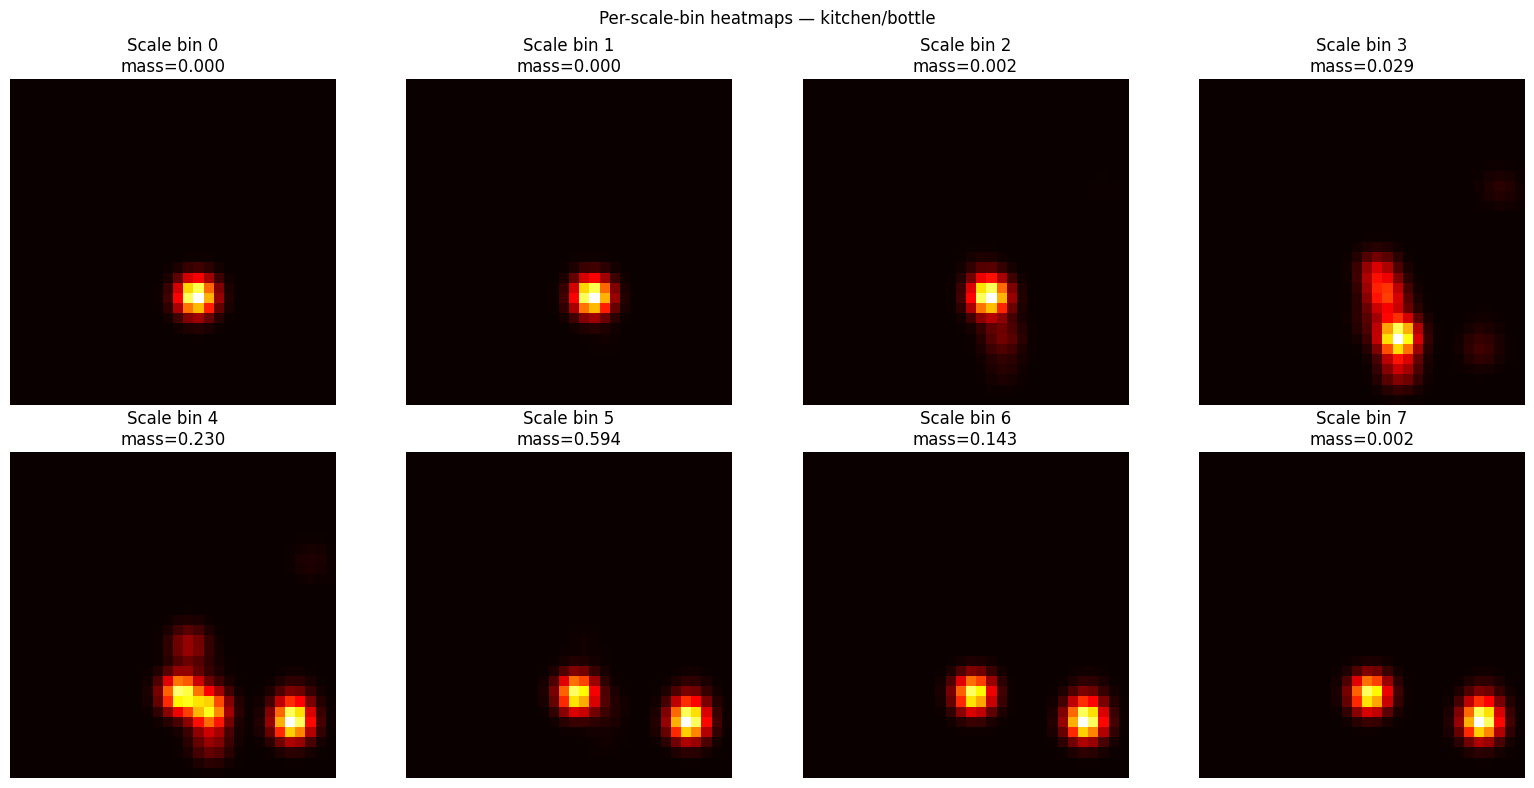

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for s in range(8):
    ax = axes[s // 4, s % 4]
    ax.imshow(target[s], cmap="hot")
    mass = target[s].sum()
    ax.set_title(f"Scale bin {s}\nmass={mass:.3f}")
    ax.axis("off")
plt.suptitle(f"Per-scale-bin heatmaps — kitchen/bottle")
plt.tight_layout()
plt.show()